<!--<badge>--><a href="https://colab.research.google.com/github/gse-unil/2026_Geoinformatique_II/blob/main/tps/tp-py02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->

[![Open in Kaggle](https://img.shields.io/badge/Open%20in-Kaggle-20BEFF?logo=kaggle&logoColor=white)](https://www.kaggle.com/kernels/welcome?src=https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/tps/tp-py02.ipynb)

[![Launch on Renku](https://renkulab.io/renku-badge.svg)]({{ MOODLE_RENKU_URL }})

> **Exécution dans le cloud** : ce notebook peut aussi tourner dans le cloud (Colab, Kaggle, Renku).
> Avant de lancer les cellules, télécharge `tp2.gpkg` (et `votation_2023.csv` / `votation_2026.csv`) depuis le dossier OneDrive du cours et dépose-le dans le répertoire de travail du notebook (Colab : panneau 📁 → *Upload* ; Kaggle : *File → Upload* ; Renku : déjà dans le projet).
> Procédure complète : [docs/cloud-badges.md](https://github.com/gse-unil/2026_Geoinformatique_II/blob/main/docs/cloud-badges.md).


# TP-PY02 — Sélections, jointures et cartographie avec GeoPandas

Ce TP est le pendant Python du **TP QGIS 02**. On travaille avec le même fichier **`tp2.gpkg`** et on effectue les mêmes opérations — sélections attributaires, requêtes spatiales, jointures et cartographie — mais en Python avec la librairie [GeoPandas](https://geopandas.org).

In [1]:
import geopandas as gpd
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


---
## 1. Chargement et exploration des données

Toutes les données sont stockées dans `tp2.gpkg`, qui contient à la fois des **couches géographiques** et des **tables attributaires** :

| Couche / Table | Type | Description |
|---|---|---|
| `Communes` | Polygone | 382 communes vaudoises |
| `geology_VD` | Polygone | Carte géologique du canton de Vaud |
| `LI_Accident_tecto` | Ligne | Accidents tectoniques |
| `BatimentsUNIL` | Polygone | Bâtiments du campus UNIL |
| `Parcelles` | Polygone | Parcelles cadastrales |
| `VoituresPlus` | Table | Véhicules / 1 000 hab. par commune (2010) |
| `Proprietaires` | Table | Propriétaires de parcelles |
| `Proprietaire_Parcelle` | Table | Table de relation parcelles ↔ propriétaires |

In [2]:
# --- Chargement des couches géographiques ---
communes  = gpd.read_file('tp2.gpkg', layer='Communes')
geologie  = gpd.read_file('tp2.gpkg', layer='geology_VD')
accidents = gpd.read_file('tp2.gpkg', layer='LI_Accident_tecto')
batiments = gpd.read_file('tp2.gpkg', layer='BatimentsUNIL')
parcelles = gpd.read_file('tp2.gpkg', layer='Parcelles')


for nom, gdf in [('Communes', communes), ('geology_VD', geologie),
                 ('LI_Accident_tecto', accidents), ('BatimentsUNIL', batiments),
                 ('Parcelles', parcelles)]:
    print(f"{nom:<25}  {str(gdf.shape):<12}  "
          f"CRS: EPSG:{gdf.crs.to_epsg()}  geom: {gdf.geom_type.unique()[0]}")

Communes                   (382, 8)      CRS: EPSG:21781  geom: MultiPolygon
geology_VD                 (784, 23)     CRS: EPSG:21781  geom: MultiPolygon
LI_Accident_tecto          (12740, 7)    CRS: EPSG:21781  geom: MultiLineString
BatimentsUNIL              (24, 6)       CRS: EPSG:21781  geom: MultiPolygon
Parcelles                  (146, 9)      CRS: EPSG:21781  geom: MultiPolygon


ERROR 1: PROJ: proj_create_from_database: Open of /home/jsoutter/anaconda3/envs/landslide/share/proj failed


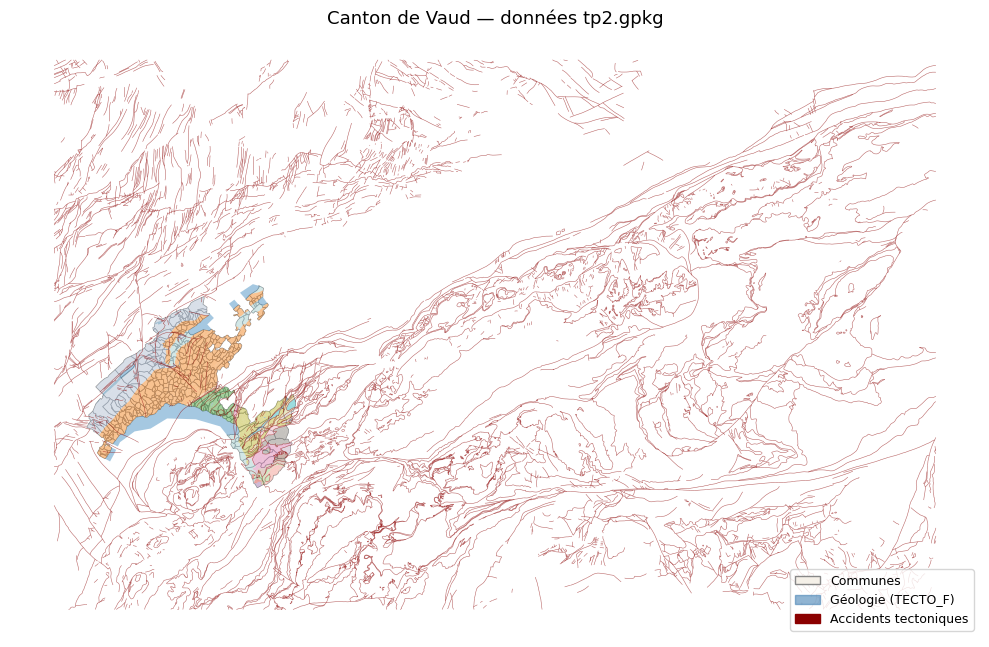

In [3]:
# --- Vue d'ensemble : superposer les couches du canton de Vaud ---
fig, ax = plt.subplots(figsize=(10, 8))

communes.plot(ax=ax, color='#f5f0e8', edgecolor='#888', linewidth=0.5)
geologie.plot(ax=ax, column='TECTO_F', cmap='tab20', alpha=0.4, legend=False)
accidents.plot(ax=ax, color='darkred', linewidth=0.4, alpha=0.6)

patches = [
    mpatches.Patch(facecolor='#f5f0e8', edgecolor='#888', label='Communes'),
    mpatches.Patch(color='steelblue', alpha=0.6, label='Géologie (TECTO_F)'),
    mpatches.Patch(color='darkred', label='Accidents tectoniques'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Canton de Vaud — données tp2.gpkg', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [4]:
# --- Tables attributaires (sans géométrie) ---
# Ces tables sont stockées dans le GeoPackage mais sans colonne géométrique.
# On les lit via sqlite3 (ou pd.read_sql).
con = sqlite3.connect('tp2.gpkg')
voitures      = pd.read_sql('SELECT * FROM VoituresPlus', con)
proprietaires = pd.read_sql('SELECT * FROM Proprietaires', con)
prop_parc     = pd.read_sql('SELECT * FROM Proprietaire_Parcelle', con)
con.close()

print(f"VoituresPlus          : {voitures.shape}  cols={voitures.columns.tolist()}")
print(f"Proprietaires         : {proprietaires.shape}  cols={proprietaires.columns.tolist()}")
print(f"Proprietaire_Parcelle : {prop_parc.shape}  cols={prop_parc.columns.tolist()}")
print()
voitures.head()

VoituresPlus          : (319, 6)  cols=['fid', 'OBJECTID', 'Communes', 'Voitures_de_tourisme', 'Motocycles', 'Voitures_de_tourisme__1000_hab']
Proprietaires         : (10, 4)  cols=['fid', 'OBJECTID', 'NO_PROPRI', 'NOM_PROPRI']
Proprietaire_Parcelle : (166, 4)  cols=['fid', 'OBJECTID', 'NO_IMM', 'NO_PROPRI']



,fid,OBJECTID,Communes,Voitures_de_tourisme,Motocycles,Voitures_de_tourisme__1000_hab
0,1,1,Aigle,4389.0,525.0,483.157199
1,2,2,Bex,3143.0,399.0,490.021827
2,3,3,Chessel,191.0,40.0,552.023121
3,4,4,Corbeyrier,217.0,24.0,554.987212
4,5,5,Gryon,750.0,112.0,629.194631


---
## 2. Requêtes attributaires

Équivalent Python des **sélections par expression** dans QGIS. En GeoPandas, on utilise :
- La **condition booléenne** : `gdf[gdf['col'] == valeur]`
- La méthode **`.isin()`** pour des sélections multiples
- La méthode **`.query()`** dont la syntaxe est proche du SQL QGIS

### 2.1 Sélection simple

> 🗺️ **Parallèle QGIS** : *Select Features by Value* sur le champ `LEG_TEC_3`.
>
> Expression QGIS équivalente :
> ```sql
> "LEG_TEC_3" = 'Nappe de Morcles (Chaine des Aravis incl.)'
> ```

Entités sélectionnées : 15
Surface totale        : 25.2 km²


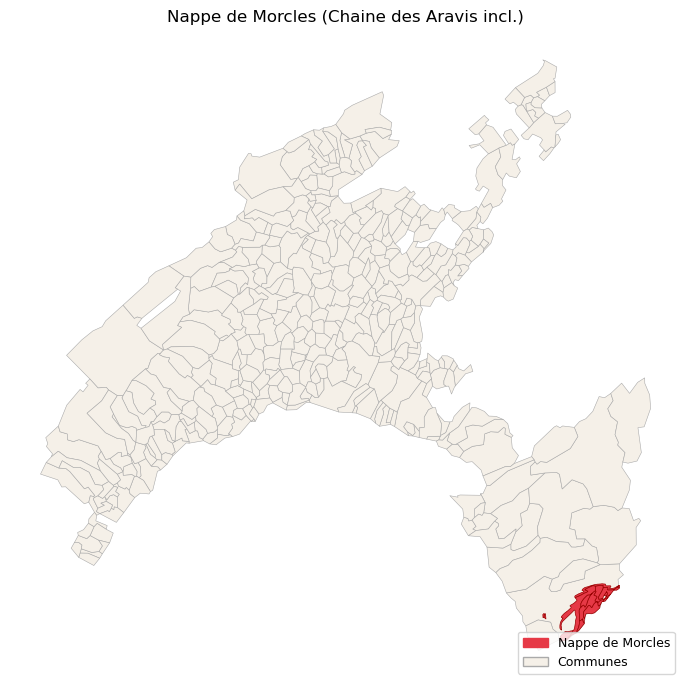

In [5]:
# --- 2.1 Sélection simple ---
nappe_morcles = geologie[
    geologie['LEG_TEC_3'] == 'Nappe de Morcles (Chaine des Aravis incl.)'
]

print(f"Entités sélectionnées : {len(nappe_morcles)}")
print(f"Surface totale        : {nappe_morcles['AREA'].sum() / 1e6:.1f} km²")

fig, ax = plt.subplots(figsize=(10, 7))
communes.plot(ax=ax, color='#f5f0e8', edgecolor='#aaa', linewidth=0.4)
nappe_morcles.plot(ax=ax, color='#e63946', edgecolor='#900', linewidth=0.5)
ax.set_title("Nappe de Morcles (Chaine des Aravis incl.)", fontsize=12)
ax.set_axis_off()
# Légende manuelle
legend_patches = [
    mpatches.Patch(color='#e63946', label='Nappe de Morcles'),
    mpatches.Patch(facecolor='#f5f0e8', edgecolor='#aaa', label='Communes'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

### 2.2 Sélection multiple — `.isin()`

Pour sélectionner plusieurs valeurs d'un même champ, on utilise `.isin()`.

> 🗺️ **Parallèle QGIS** :
> ```sql
> "PRODUCTIV" IN ('Peu productifs, dans les moraines',
>                 'Productif, a productivite variable ou faible')
> ```

Entités sélectionnées : 334

Répartition par classe :
PRODUCTIV
Productif, a productivite variable ou faible    177
Peu productifs, dans les moraines               157


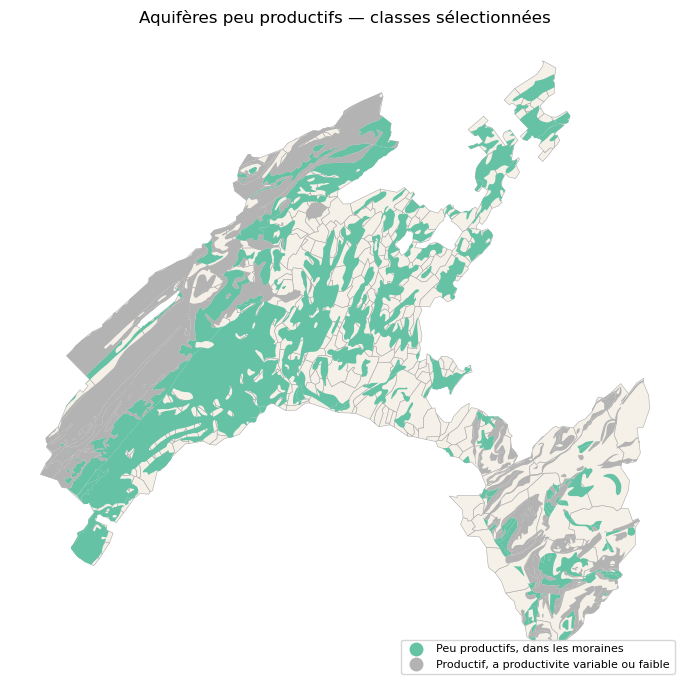

In [6]:
# --- 2.2 Sélection multiple avec .isin() ---
productivites = [
    'Peu productifs, dans les moraines',
    'Productif, a productivite variable ou faible'
]
peu_productifs = geologie[geologie['PRODUCTIV'].isin(productivites)]

print(f"Entités sélectionnées : {len(peu_productifs)}")
print()
print("Répartition par classe :")
print(peu_productifs['PRODUCTIV'].value_counts().to_string())

fig, ax = plt.subplots(figsize=(10, 7))
communes.plot(ax=ax, color='#f5f0e8', edgecolor='#aaa', linewidth=0.4)
peu_productifs.plot(ax=ax, column='PRODUCTIV', cmap='Set2', legend=True,
                    legend_kwds={'loc': 'lower right', 'fontsize': 8})
ax.set_title("Aquifères peu productifs — classes sélectionnées", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 2.3 Sélection par intervalle

> 🗺️ **Parallèle QGIS** :
> ```sql
> "AREA" >= 100000 AND "AREA" <= 500000
> ```
>
> Sélectionner les unités géologiques dont la surface est comprise entre **0.1 km²** et **0.5 km²**.

In [7]:
# --- 2.3 Sélection par intervalle ---
petites_unites = geologie[
    (geologie['AREA'] >= 100_000) &
    (geologie['AREA'] <= 500_000)
]

print(f"Entités sélectionnées : {len(petites_unites)}")
print(f"Surface min / max     : {petites_unites['AREA'].min()/1e6:.3f} – "
      f"{petites_unites['AREA'].max()/1e6:.3f} km²")
print()
print("Top 8 unités les plus grandes dans la sélection :")
print(petites_unites[['OBJECTID', 'LEG_TEC_3', 'AREA']]
      .sort_values('AREA', ascending=False).head(8).to_string(index=False))

Entités sélectionnées : 257
Surface min / max     : 0.101 – 0.499 km²

Top 8 unités les plus grandes dans la sélection :
 OBJECTID                              LEG_TEC_3         AREA
      371 Nappe des Prealpes medianes plastiques 499113.76660
       59        Molasse du plateau non deformee 497617.47903
      597 Nappe des Prealpes medianes plastiques 497112.90123
      405 Nappe des Prealpes medianes plastiques 495606.51972
      416                                        493335.01153
      121        Molasse du plateau non deformee 488855.05078
      675        Molasse du plateau non deformee 483708.52763
      684                                        483411.69578


### 2.4 La méthode `.query()`

`.query()` permet d'exprimer des conditions sous forme de chaîne de caractères,
proche de la **syntaxe SQL** utilisée dans QGIS.

```python
# Condition simple
gdf.query("col == 'valeur'")

# Intervalle
gdf.query("col >= 100 and col <= 500")

# Variable externe (préfixe @)
seuil = 1000
gdf.query("col > @seuil")
```

In [8]:
# --- 2.4 Requêtes avec .query() ---

# Sélection simple
nappe_q = geologie.query("LEG_TEC_3 == 'Nappe de Morcles (Chaine des Aravis incl.)'")

# Sélection par intervalle
petites_q = geologie.query("AREA >= 100_000 and AREA <= 500_000")

# Variable externe (préfixe @)
seuil_bas, seuil_haut = 1_000_000, 10_000_000
grandes_unites = geologie.query("AREA >= @seuil_bas and AREA <= @seuil_haut")

# Condition combinée avec méthode de chaîne (nécessite engine='python')
molasse = geologie.query(
    "LEG_TEC_3.str.contains('Molasse', na=False) and AREA > 1_000_000",
    engine='python'
)

print(f"Nappe de Morcles         : {len(nappe_q)} entités")
print(f"Petites unités (0.1–0.5 km²) : {len(petites_q)} entités")
print(f"Grandes unités (1–10 km²): {len(grandes_unites)} entités")
print(f"Molasse (> 1 km²)        : {len(molasse)} entités")

Nappe de Morcles         : 15 entités
Petites unités (0.1–0.5 km²) : 257 entités
Grandes unités (1–10 km²): 270 entités
Molasse (> 1 km²)        : 101 entités


---
## 3. Requêtes spatiales

> 🗺️ **Parallèle QGIS** : *Sélection par localisation* (*Select by Location*)

Une **requête spatiale** sélectionne des entités en fonction de leur relation géométrique avec d'autres entités. Ici on combine :

1. **Filtrage attributaire** — ne garder que les chevauchements principaux alpins
2. **Filtrage spatial** — parmi ceux-ci, ne conserver que ceux qui intersectent le territoire vaudois (couche `Communes`)

Chevauchements alpins (total dataset)  : 6965
Type
Chevauchement principal alpin (certain)     5069
Chevauchement principal alpin (probable)    1896

Chevauchements dans Vaud               : 235


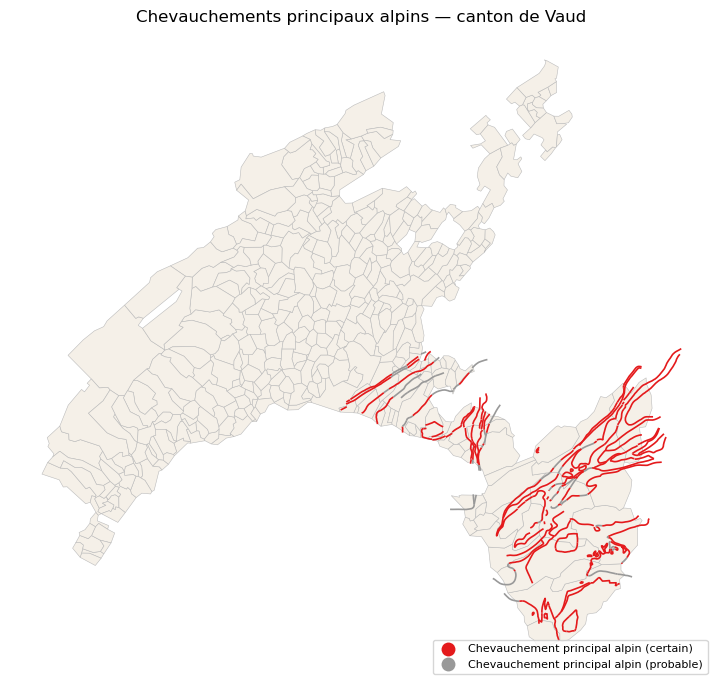

In [9]:
# --- 3. Requête spatiale : chevauchements alpins dans Vaud ---

# Étape 1 : sélection attributaire
types_chev = [
    'Chevauchement principal alpin (certain)',
    'Chevauchement principal alpin (probable)'
]
chev = accidents[accidents['Type'].isin(types_chev)].copy()
print(f"Chevauchements alpins (total dataset)  : {len(chev)}")
print(chev['Type'].value_counts().to_string())

# Étape 2 : sélection spatiale
# gpd.sjoin(predicate='intersects') → garde les lignes qui croisent un polygone communal
chev_vaud = gpd.sjoin(
    chev,
    communes[['geometry']],
    how='inner',
    predicate='intersects'
)
chev_vaud = chev_vaud[~chev_vaud.index.duplicated()]   # supprimer les doublons
print(f"\nChevauchements dans Vaud               : {len(chev_vaud)}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 7))
communes.plot(ax=ax, color='#f5f0e8', edgecolor='#bbb', linewidth=0.4)
chev_vaud.plot(ax=ax, column='Type', cmap='Set1', linewidth=1.2,
               legend=True, legend_kwds={'loc': 'lower right', 'fontsize': 8})
ax.set_title('Chevauchements principaux alpins — canton de Vaud', fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

---
## 4. Jointures

Les jointures permettent de **combiner deux tables** sur la base d'un attribut commun (jointure attributaire) ou d'une relation géométrique (jointure spatiale).

### 4.1 Jointure attributaire — `merge()`

> 🗺️ **Parallèle QGIS** : *Jointures* dans les propriétés de la couche.

On joint la table `VoituresPlus` (véhicules / 1 000 hab.) à la couche `Communes` via les champs `NAME` ↔ `Communes`.

In [10]:
voitures.head()
batiments.head()

,OBJECTID,name,amenity,Shape_Length,Shape_Area,geometry
0,1,Unithèque,library,373.945152,6539.066443,"MULTIPOLYGON (((534143.836 152791.372, 534144...."
1,2,Ferme de Dorigny,university,70.615270,-307.671493,"MULTIPOLYGON (((534286.783 152883.348, 534297...."
2,3,Institut Suisse de Droit Comparé,university,197.919412,1621.000529,"MULTIPOLYGON (((534307.963 152655.291, 534346...."
3,4,Internef,university,468.743164,8242.915279,"MULTIPOLYGON (((534381.924 152689.046, 534397...."
4,5,Anthropole,university,519.860269,-8291.707994,"MULTIPOLYGON (((534456.495 152775.258, 534485...."


In [11]:
# --- 4.1 Jointure attributaire ---
communes_voit = communes.merge(
    voitures[['Communes', 'Voitures_de_tourisme', 'Voitures_de_tourisme__1000_hab']],
    left_on='NAME',
    right_on='Communes',
    how='left'
)

print(f"Résultat : {communes_voit.shape}")
print(f"Communes sans données  : "
      f"{communes_voit['Voitures_de_tourisme__1000_hab'].isna().sum()} / {len(communes_voit)}")
print()
top10 = (communes_voit.dropna(subset=['Voitures_de_tourisme__1000_hab'])
         .sort_values('Voitures_de_tourisme__1000_hab', ascending=False)
         .head(10))
print("Top 10 communes — véhicules / 1 000 hab. :")
print(top10[['NAME', 'Voitures_de_tourisme', 'Voitures_de_tourisme__1000_hab']]
      .to_string(index=False))

Résultat : (382, 11)
Communes sans données  : 82 / 382

Top 10 communes — véhicules / 1 000 hab. :
                NAME  Voitures_de_tourisme  Voitures_de_tourisme__1000_hab
            Bursinel                 509.0                     1043.032787
Villars-Sainte-Croix                 620.0                      925.373134
              Aclens                 435.0                      921.610169
  Chavannes-de-Bogis                 835.0                      877.100840
        Signy-Avenex                 372.0                      865.116279
                Mies                1410.0                      852.994555
              Cuarny                 144.0                      842.105263
           Bremblens                 398.0                      830.897704
       Bougy-Villars                 366.0                      824.324324
           Echandens                1756.0                      801.460520


### 4.2 Jointure spatiale — `sjoin()`

> 🗺️ **Parallèle QGIS** : *Join Attributes by Location* (outil de géotraitement).

On veut savoir dans quelle **commune** se trouve chaque **bâtiment du campus UNIL**.
`gpd.sjoin()` compare les géométries des deux couches et associe les attributs de la commune au bâtiment qui s'y trouve.

In [12]:
# --- 4.2 Jointure spatiale : bâtiments UNIL → commune ---
# predicate='intersects' pour capturer aussi les bâtiments sur les limites
bat_communes = gpd.sjoin(
    batiments,
    communes[['NAME', 'BEZIRK', 'geometry']],
    how='left',
    predicate='intersects'
)
# Un bâtiment peut intersectar plusieurs communes : garder la première occurrence
bat_communes = bat_communes[~bat_communes.index.duplicated(keep='first')]

print(f"Résultat : {bat_communes.shape}")
print()
print("Commune de chaque bâtiment UNIL :")
print(bat_communes[['name', 'amenity', 'NAME', 'BEZIRK']]
      .sort_values('NAME').to_string(index=False))

Résultat : (24, 9)

Commune de chaque bâtiment UNIL :
                            name          amenity                  NAME  BEZIRK
              Château de Dorigny       university Chavannes-près-Renens    2209
    Bibliothèque Edouard Fleuret       university Chavannes-près-Renens    2209
             Archives Cantonales       university Chavannes-près-Renens    2209
             Ferme de la Mouline       university Chavannes-près-Renens    2209
                        Geopolis       university Chavannes-près-Renens    2209
               Grange de Dorigny       university Chavannes-près-Renens    2209
                        Bergerie       university Chavannes-près-Renens    2209
                Ferme de Dorigny       university Chavannes-près-Renens    2209
                        Internef       university Chavannes-près-Renens    2209
                      Anthropole       university Chavannes-près-Renens    2209
                       Unicentre       university         Ecublens

### 4.3 Relations plusieurs-à-plusieurs (N-N)

> 🗺️ **Parallèle QGIS** : *Relations* dans les propriétés du projet QGIS.

Une **relation N-N** permet d'associer plusieurs propriétaires à une même parcelle (et vice-versa), via une **table intermédiaire** :

```
Parcelles ──(NO_IMM)──► Proprietaire_Parcelle ──(NO_PROPRI)──► Proprietaires
```

En Python, on enchaîne deux `merge()`.

In [13]:
# --- 4.3 Relations N-N : Parcelles ↔ Propriétaires ---
# Jointure en chaîne : Parcelles → Proprietaire_Parcelle → Proprietaires
parcelles_propri = (
    parcelles[['NO_IMM', 'NO_COMMUNE', 'SURFACE_RF', 'geometry']]
    .merge(prop_parc[['NO_IMM', 'NO_PROPRI']], on='NO_IMM', how='left')
    .merge(proprietaires[['NO_PROPRI', 'NOM_PROPRI']], on='NO_PROPRI', how='left')
)

print(f"Résultat : {parcelles_propri.shape}")
print(f"(une ligne par couple parcelle–propriétaire)")
print()

# Parcelles avec plusieurs propriétaires
multi_propri = (parcelles_propri.groupby('NO_IMM')
                .filter(lambda x: len(x) > 1)
                .sort_values('NO_IMM'))
print("Parcelles avec plusieurs propriétaires :")
print(multi_propri[['NO_IMM', 'SURFACE_RF', 'NO_PROPRI', 'NOM_PROPRI']]
      .to_string(index=False))

Résultat : (172, 6)
(une ligne par couple parcelle–propriétaire)

Parcelles avec plusieurs propriétaires :
NO_IMM  SURFACE_RF  NO_PROPRI     NOM_PROPRI
  1228       994.0          1       Aristote
  1228       994.0          3      Descartes
  1228       994.0          5         Thalès
  1228       994.0          7      Pythagore
   414      1700.0          7      Pythagore
   414      1700.0          1       Aristote
   437       761.0          6        Euclide
   437       761.0          1       Aristote
   457       608.0          7      Pythagore
   457       608.0          3      Descartes
   457       608.0          2       Ptolémée
   468      1787.0          9    Ératosthène
   468      1787.0          8         Pascal
   537       960.0          4         Platon
   537       960.0          9    Ératosthène
   537       960.0          8         Pascal
   559       657.0          7      Pythagore
   559       657.0          2       Ptolémée
   559       657.0          6        E

---
## 5. Cartographie choroplèthe

Une **carte choroplèthe** colore les polygones en fonction d'un attribut numérique. On visualise la densité de voitures par commune, issue de la jointure attributaire réalisée à la section 4.1.

### 5.1 Carte simple

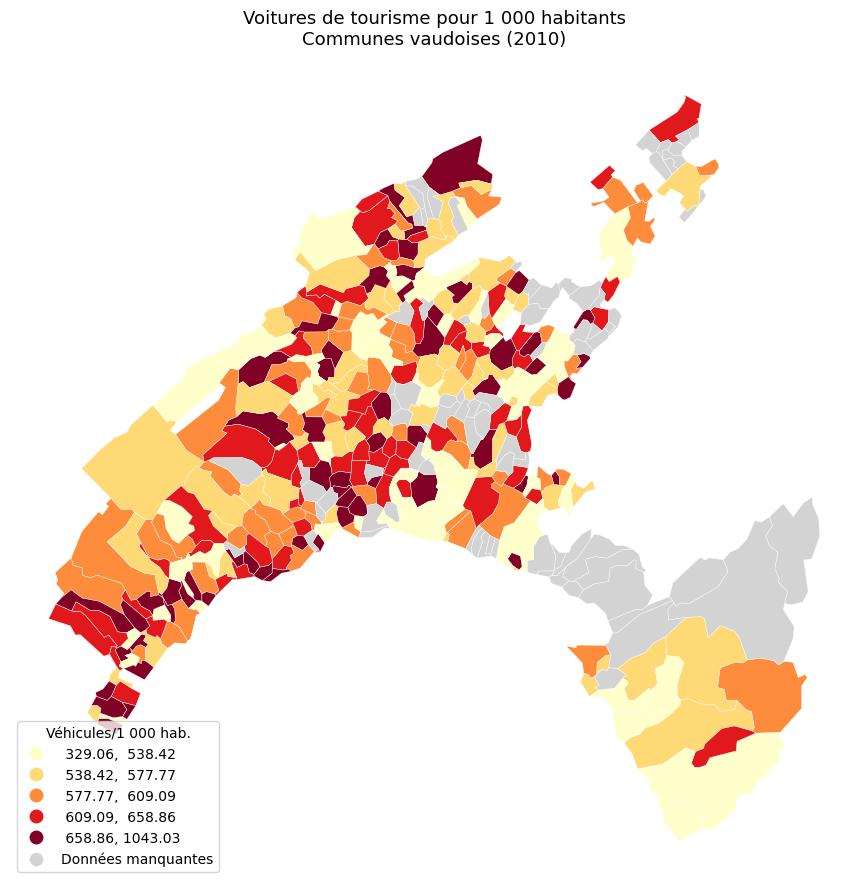

In [14]:
# --- 5.1 Choroplèthe : véhicules / 1 000 hab. par commune ---
fig, ax = plt.subplots(figsize=(12, 9))

communes_voit.plot(
    ax=ax,
    column='Voitures_de_tourisme__1000_hab',
    cmap='YlOrRd',
    scheme='quantiles',
    k=5,
    legend=True,
    legend_kwds={'title': 'Véhicules/1 000 hab.', 'loc': 'lower left'},
    edgecolor='white',
    linewidth=0.3,
    missing_kwds={'color': 'lightgrey', 'label': 'Données manquantes'}
)

ax.set_title('Voitures de tourisme pour 1 000 habitants\nCommunes vaudoises (2010)',
             fontsize=13, pad=10)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### 5.2 Méthodes de discrétisation

Le choix de la **méthode de classification** influence fortement la lecture de la carte.

| Méthode (`scheme=`) | Description |
|---|---|
| `'quantiles'` | Classes contenant le même nombre d'entités |
| `'equal_interval'` | Classes de même amplitude (intervalle de valeurs) |
| `'natural_breaks'` (Jenks) | Minimise la variance intra-classe |

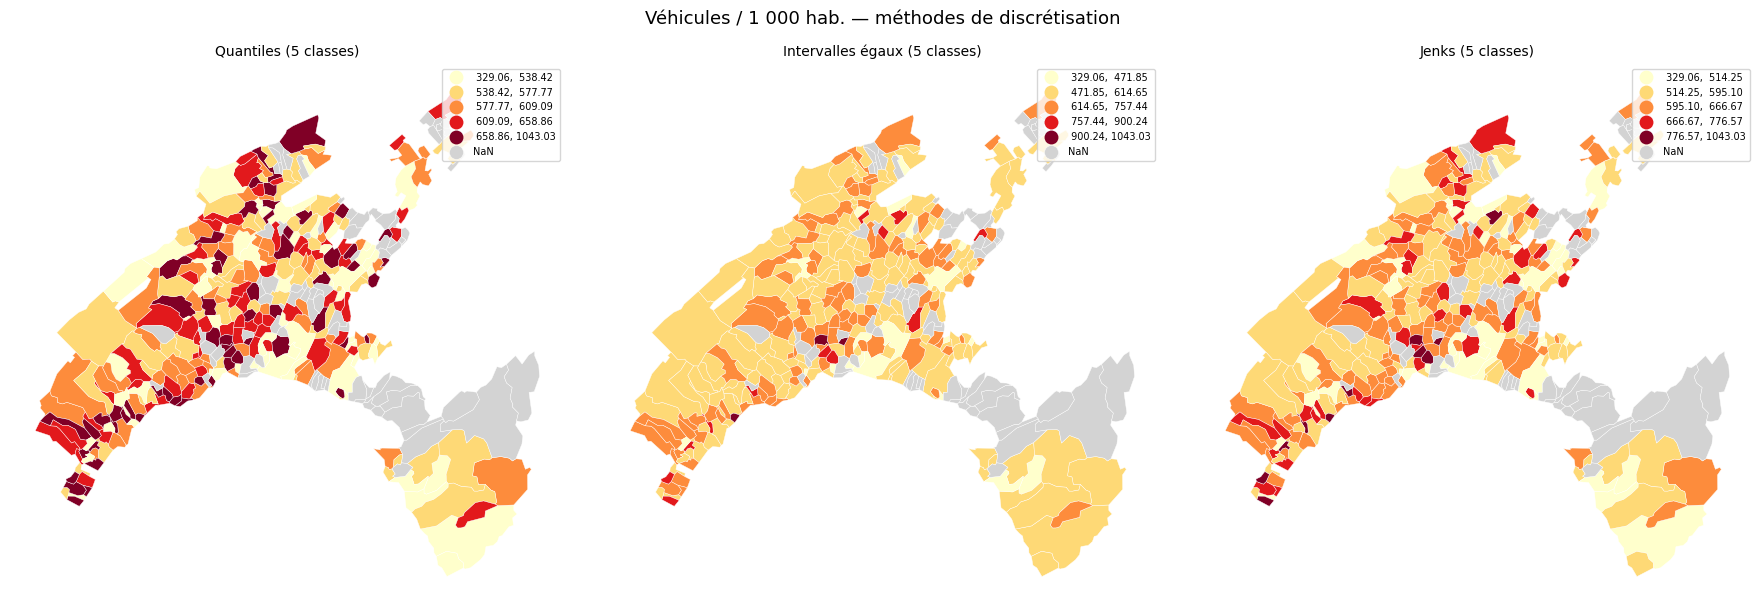

In [15]:
# --- 5.2 Comparaison des méthodes de discrétisation ---
methodes = ['quantiles', 'equal_interval', 'natural_breaks']
titres   = ['Quantiles (5 classes)', 'Intervalles égaux (5 classes)', 'Jenks (5 classes)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, methode, titre in zip(axes, methodes, titres):
    communes_voit.plot(
        ax=ax,
        column='Voitures_de_tourisme__1000_hab',
        cmap='YlOrRd', scheme=methode, k=5,
        legend=True, legend_kwds={'fontsize': 7},
        edgecolor='white', linewidth=0.3,
        missing_kwds={'color': 'lightgrey'}
    )
    ax.set_title(titre, fontsize=10)
    ax.set_axis_off()

plt.suptitle("Véhicules / 1 000 hab. — méthodes de discrétisation", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

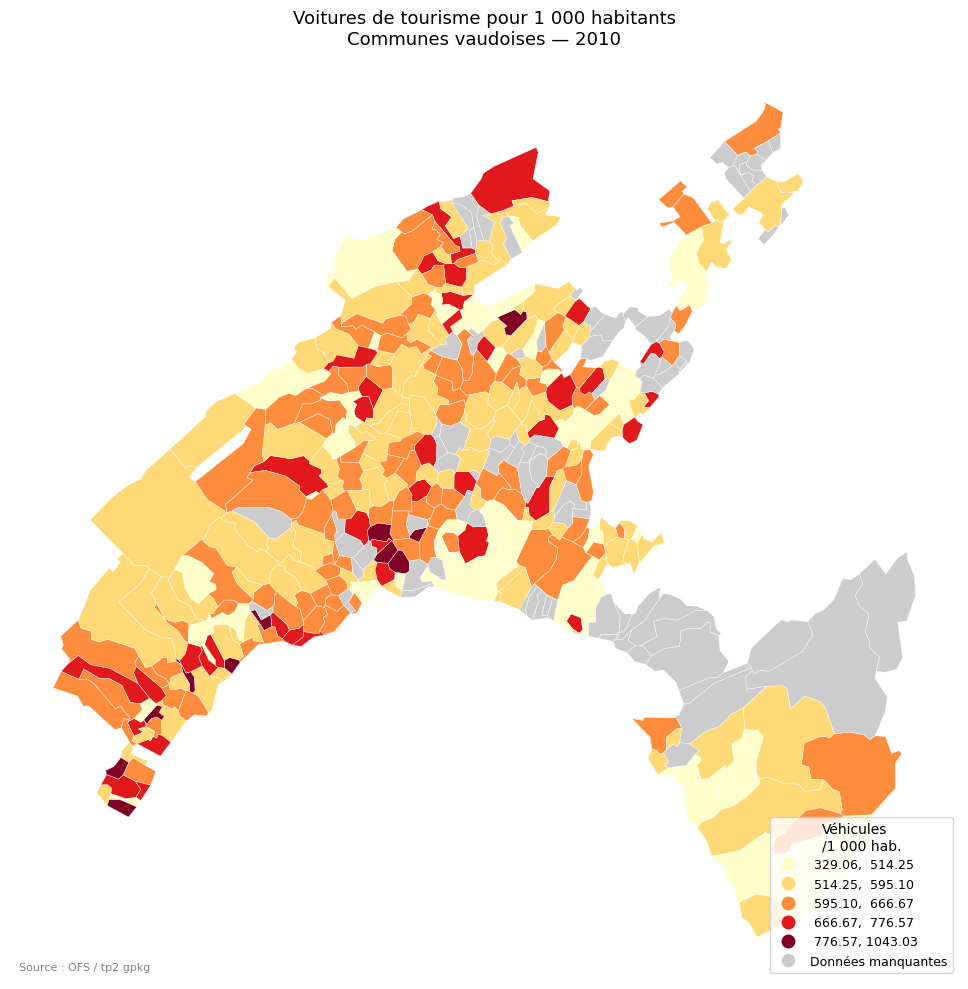

In [16]:
# --- Carte choroplèthe complète avec éléments cartographiques ---
fig, ax = plt.subplots(figsize=(12, 10))

communes_voit.plot(
    ax=ax,
    column='Voitures_de_tourisme__1000_hab',
    cmap='YlOrRd',
    scheme='natural_breaks', k=5,
    legend=True,
    legend_kwds={
        'title': 'Véhicules\n/1 000 hab.',
        'loc': 'lower right',
        'fontsize': 9,
        'title_fontsize': 10,
    },
    edgecolor='white', linewidth=0.3,
    missing_kwds={'color': '#cccccc', 'label': 'Données manquantes'}
)

ax.set_title("Voitures de tourisme pour 1 000 habitants\nCommunes vaudoises — 2010",
             fontsize=13, pad=12)
ax.set_axis_off()
ax.annotate('Source : OFS / tp2.gpkg', xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')
plt.tight_layout()
plt.show()

---
## 6. Export

Une fois les données traitées, on peut les sauvegarder dans différents formats pour les partager ou les ouvrir dans QGIS.

| Format | Extension | Avantages |
|---|---|---|
| GeoJSON | `.geojson` | Lisible par tous, idéal pour le web |
| GeoPackage | `.gpkg` | Plusieurs couches, prise en charge de tous les CRS |
| Shapefile | `.shp` | Compatibilité maximale (mais limité à 1 couche) |

In [17]:
import os

os.makedirs('sortie', exist_ok=True)

# 1. Jointure communes + voitures → GeoJSON (WGS84 pour portabilité web)
communes_voit_exp = communes_voit.drop(columns=['Communes'], errors='ignore')
communes_voit_wgs84 = communes_voit_exp.to_crs(epsg=4326)
communes_voit_wgs84.to_file('sortie/communes_voitures.geojson', driver='GeoJSON')
print("GeoJSON sauvegardé : sortie/communes_voitures.geojson")

# 2. Chevauchements alpins dans Vaud + bâtiments UNIL → GeoPackage (MN03)
chev_vaud.to_file('sortie/resultats.gpkg', layer='chevauchements_vaud', driver='GPKG')
batiments.to_file('sortie/resultats.gpkg', layer='batiments_unil',      driver='GPKG')
print("GeoPackage sauvegardé : sortie/resultats.gpkg (2 couches)")

# 3. Nappe de Morcles → GeoJSON WGS84
nappe_morcles.to_crs(epsg=4326).to_file('sortie/nappe_morcles_wgs84.geojson', driver='GeoJSON')
print("GeoJSON sauvegardé : sortie/nappe_morcles_wgs84.geojson")

GeoJSON sauvegardé : sortie/communes_voitures.geojson
GeoPackage sauvegardé : sortie/resultats.gpkg (2 couches)
GeoJSON sauvegardé : sortie/nappe_morcles_wgs84.geojson


In [18]:
# --- Vérification : relire les fichiers exportés ---
comm_relu  = gpd.read_file('sortie/communes_voitures.geojson')
nappe_relu = gpd.read_file('sortie/nappe_morcles_wgs84.geojson')
chev_relu  = gpd.read_file('sortie/resultats.gpkg', layer='chevauchements_vaud')

print(f"communes_voitures.geojson    : {comm_relu.shape[0]} entités  CRS = {comm_relu.crs}")
print(f"nappe_morcles_wgs84.geojson  : {nappe_relu.shape[0]} entités  CRS = {nappe_relu.crs}")
print(f"chevauchements_vaud (gpkg)   : {chev_relu.shape[0]} entités  CRS = {chev_relu.crs}")

communes_voitures.geojson    : 382 entités  CRS = EPSG:4326
nappe_morcles_wgs84.geojson  : 15 entités  CRS = EPSG:4326
chevauchements_vaud (gpkg)   : 235 entités  CRS = EPSG:21781


In [19]:
# --- Projection : reprojeter les communes en WGS84 ---
# Toutes les couches de tp2.gpkg sont en MN03 (EPSG:21781).
# On peut les reprojeter pour d'autres usages (web, GeoJSON standard, etc.)
communes_wgs84 = communes.to_crs(epsg=4326)

print(f"CRS initial  : {communes.crs}")
print(f"CRS WGS84    : {communes_wgs84.crs}")
print(f"Bounds MN03  : {[round(x) for x in communes.total_bounds]}")
print(f"Bounds WGS84 : {[round(x, 4) for x in communes_wgs84.total_bounds]}")

CRS initial  : EPSG:21781
CRS WGS84    : EPSG:4326
Bounds MN03  : [494305, 115143, 585425, 203348]
Bounds WGS84 : [6.0638, 46.187, 7.2487, 46.9805]


---
## 7. Régression linéaire et validation

Jusqu'ici, ce TP s'est concentré sur les **géotraitements vectoriels**. Cette dernière partie ouvre un fil conducteur qui se poursuit au TP03 et au TP04 : construire un modèle prédictif ne suffit pas, il faut aussi savoir répondre à trois questions que tout projet de modélisation pose tôt ou tard :

1. **Quel modèle choisir ?** — ici on n'a qu'un seul modèle (OLS) ; comparer plusieurs modèles arrive au TP03 (§4.7) et au TP04 (§7.2).
2. **Comment le valider ?** — train/test ici (§7.5) ; K-fold CV au TP03 ; un jeu de validation dédié au TP04.
3. **Comment quantifier son incertitude ?** — IC vs IP ici (§7.3) ; CV répétée et bootstrap au TP03 ; prédiction conforme au TP04.

On combine des données attributaires (résultats de votation) et les géométries des communes suisses pour répondre à une question prédictive concrète :

> **Peut-on prédire le résultat de l'Initiative 10 millions (2026) à partir du vote pour la Loi Climat (2023) ?**

| Votation | Date | Description courte | Résultat national |
|---|---|---|---|
| **Loi Climat (LCI)** | juin 2023 | Loi sur la protection du climat et l'innovation énergétique | acceptée (59 %) |
| **Initiative 10 millions** | juin 2026 | Initiative pour la durabilité démographique | rejetée (39 %) |

Ces deux votations mobilisent des clivages politiques similaires (économie vs écologie, urbain vs rural). On s'attend donc à une corrélation forte à l'échelle communale — qu'on va quantifier, modéliser et valider.

### 7.1 Chargement et préparation des données

In [20]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# --- Chargement des résultats de votation ---
v23_raw = pd.read_csv('votation_2023.csv', sep=';')
v26_raw = pd.read_csv('votation_2026.csv', sep=';')

# Niveau communal uniquement, filtre par identifiant de scrutin
lci = v23_raw[(v23_raw['region_type'] == 'municipality') &
              (v23_raw['proposal_id'] == 6630)].copy()   # Loi Climat
m10 = v26_raw[(v26_raw['region_type'] == 'municipality') &
              (v26_raw['proposal_id'] == 6860)].copy()   # Initiative 10M

lci['oui_pct_lci'] = lci['yes_votes_count'] / lci['cast_votes_count'] * 100
m10['oui_pct_m10'] = m10['yes_votes_count'] / m10['cast_votes_count'] * 100

# Jointure interne sur l'identifiant communal : seules les communes présentes
# dans les deux scrutins sont conservées
df = (lci[['region_id', 'region_name', 'parent_canton_name', 'oui_pct_lci']]
      .merge(m10[['region_id', 'oui_pct_m10']], on='region_id')
      .dropna())

print(f"Communes retenues : {len(df)}")
print(f"  LCI — taux OUI : moy={df['oui_pct_lci'].mean():.1f}%  "
      f"[{df['oui_pct_lci'].min():.1f} – {df['oui_pct_lci'].max():.1f}%]")
print(f"  10M — taux OUI : moy={df['oui_pct_m10'].mean():.1f}%  "
      f"[{df['oui_pct_m10'].min():.1f} – {df['oui_pct_m10'].max():.1f}%]")
df.head()

Communes retenues : 2099
  LCI — taux OUI : moy=50.6%  [7.5 – 82.4%]
  10M — taux OUI : moy=52.1%  [16.3 – 90.4%]


,region_id,region_name,parent_canton_name,oui_pct_lci,oui_pct_m10
0,1,Aeugst am Albis,Zurich,56.777494,48.967552
1,2,Affoltern am Albis,Zurich,59.676908,44.468237
2,3,Bonstetten,Zurich,62.506527,41.278398
3,4,Hausen am Albis,Zurich,57.660377,44.450431
4,5,Hedingen,Zurich,58.076095,41.094361


### 7.2 Corrélation et visualisation

Avant de modéliser, on quantifie le **lien linéaire** entre les deux variables avec le **coefficient de Pearson**

$$r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\sqrt{\sum_i (y_i - \bar{y})^2}}$$

qui varie de −1 (corrélation négative parfaite) à +1 (corrélation positive parfaite), 0 indiquant l'absence de lien linéaire.

Le **coefficient de détermination** $R^2$ mesure la proportion de variance de $y$ expliquée par le modèle :

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

où $SS_{res}$ est la somme des carrés des résidus (l'erreur du modèle) et $SS_{tot}$ la variance totale de $y$ autour de sa moyenne. $R^2 = 1$ signifie un ajustement parfait ; $R^2 = 0$ signifie que le modèle ne fait pas mieux que prédire systématiquement la moyenne $\bar{y}$. **Pour une régression linéaire simple à un seul prédicteur, $R^2 = r^2$** — c'est ce qu'on vérifie numériquement ci-dessous. Pour un modèle à plusieurs prédicteurs (TP03), $R^2$ reste défini par cette formule générale, même si $r$ n'a plus de sens univarié.

Une corrélation négative est attendue ici : les communes qui ont massivement voté OUI à la Loi Climat (sensibilité environnementale élevée) ont tendance à rejeter l'Initiative 10 millions (perçue comme anti-immigration ou anti-croissance), et vice-versa.

r = -0.891   p-value = 0.00e+00
→ Corrélation forte et négative (R² = 0.794)


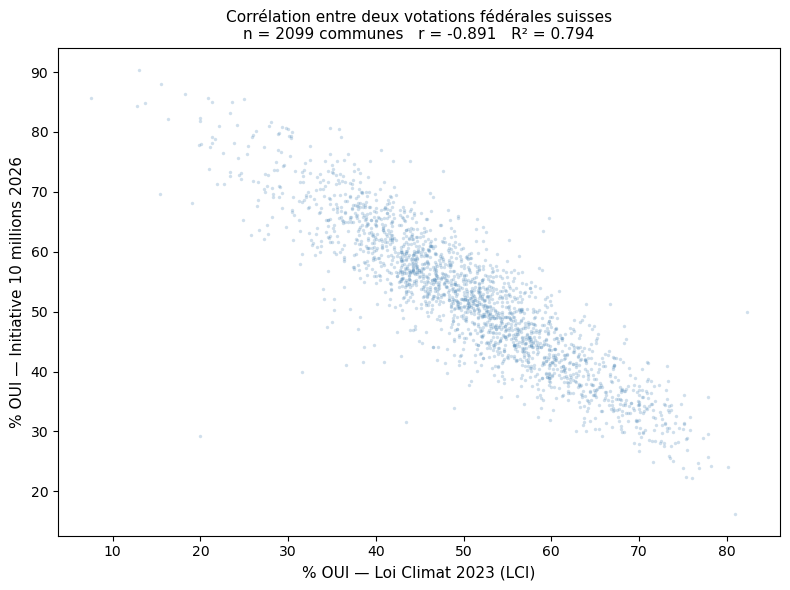

In [21]:
r, p_val = stats.pearsonr(df['oui_pct_lci'], df['oui_pct_m10'])
print(f"r = {r:.3f}   p-value = {p_val:.2e}")
print(f"→ Corrélation {'forte' if abs(r)>0.7 else 'modérée'} et "
      f"{'négative' if r < 0 else 'positive'} (R² = {r**2:.3f})")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['oui_pct_lci'], df['oui_pct_m10'],
           alpha=0.25, s=6, color='steelblue', linewidths=0)
ax.set_xlabel('% OUI — Loi Climat 2023 (LCI)', fontsize=11)
ax.set_ylabel('% OUI — Initiative 10 millions 2026', fontsize=11)
ax.set_title(f'Corrélation entre deux votations fédérales suisses\n'
             f'n = {len(df)} communes   r = {r:.3f}   R² = {r**2:.3f}', fontsize=11)
plt.tight_layout()
plt.show()

### 7.3 Régression OLS — intervalles de confiance et de prédiction

La régression OLS (*Ordinary Least Squares*) ajuste une droite $\hat{y} = a \cdot x + b$ qui minimise la somme des carrés des résidus.

`statsmodels` fournit deux types d'intervalles autour de cette droite :

| Intervalle | Signification | Largeur |
|---|---|---|
| **Intervalle de confiance (IC)** | Incertitude sur la **moyenne** de $y$ pour une valeur de $x$ donnée | Étroit |
| **Intervalle de prédiction (IP)** | Incertitude sur une **observation individuelle** pour la même valeur de $x$ | Large (inclut la variance résiduelle) |

En pratique : l'IC s'applique pour estimer la tendance centrale, l'IP pour prédire une commune spécifique.

                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      98.0527      0.524    187.212      0.000      97.026      99.080
oui_pct_lci    -0.9072      0.010    -89.831      0.000      -0.927      -0.887

R² = 0.794


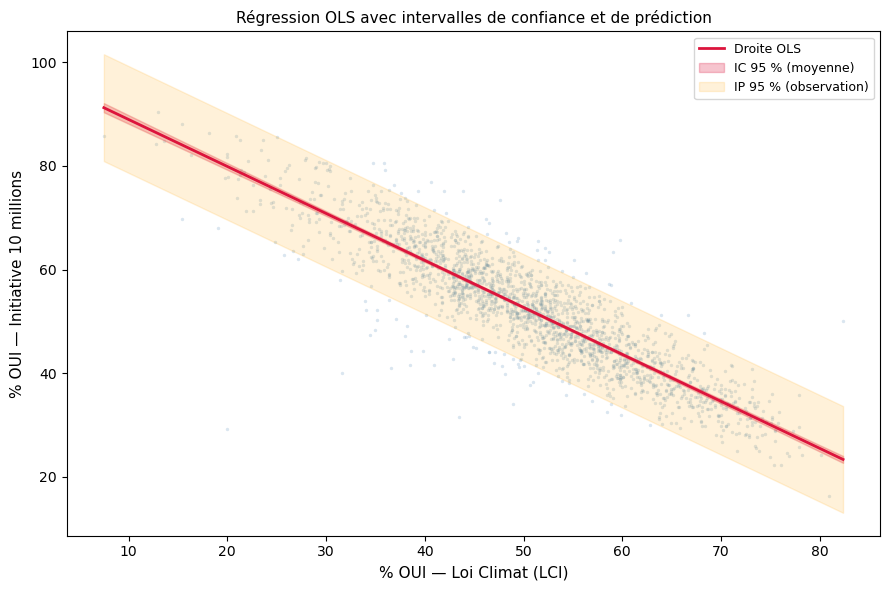

In [22]:
# Ajustement OLS avec statsmodels (formule R-like)
model_ols = smf.ols('oui_pct_m10 ~ oui_pct_lci', data=df).fit()
print(model_ols.summary().tables[1])   # tableau des coefficients seulement
print(f"\nR² = {model_ols.rsquared:.3f}")

# Prédictions sur une grille régulière pour tracer IC et IP
x_grid = pd.DataFrame({'oui_pct_lci': np.linspace(df['oui_pct_lci'].min(),
                                                    df['oui_pct_lci'].max(), 300)})
pred = model_ols.get_prediction(x_grid).summary_frame(alpha=0.05)
# Colonnes : mean, mean_ci_lower, mean_ci_upper, obs_ci_lower, obs_ci_upper

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['oui_pct_lci'], df['oui_pct_m10'],
           alpha=0.2, s=6, color='steelblue', linewidths=0, zorder=1)
ax.plot(x_grid['oui_pct_lci'], pred['mean'],
        color='crimson', linewidth=2, label='Droite OLS', zorder=3)
ax.fill_between(x_grid['oui_pct_lci'], pred['mean_ci_lower'], pred['mean_ci_upper'],
                color='crimson', alpha=0.25, label='IC 95 % (moyenne)', zorder=2)
ax.fill_between(x_grid['oui_pct_lci'], pred['obs_ci_lower'], pred['obs_ci_upper'],
                color='orange', alpha=0.15, label='IP 95 % (observation)', zorder=2)
ax.set_xlabel('% OUI — Loi Climat (LCI)', fontsize=11)
ax.set_ylabel('% OUI — Initiative 10 millions', fontsize=11)
ax.set_title('Régression OLS avec intervalles de confiance et de prédiction', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 7.4 Surapprentissage (*overfitting*)

Un modèle avec trop de **paramètres libres** par rapport au nombre d'observations peut coller presque parfaitement aux données d'entraînement — bruit compris. Il **mémorise** l'échantillon au lieu d'apprendre la tendance réelle, et généralise mal à de nouvelles données : c'est le **surapprentissage** (*overfitting*).

Pour le voir concrètement, on compare une droite (peu flexible, 2 paramètres) à un polynôme de degré 6 (très flexible, 7 paramètres), tous deux ajustés sur un **petit échantillon de 15 communes**. Avec aussi peu de points, un modèle flexible a la place d'onduler entre chaque observation plutôt que de suivre la tendance générale.

On évalue ensuite les deux modèles sur les communes **restantes**, jamais vues lors de l'ajustement.

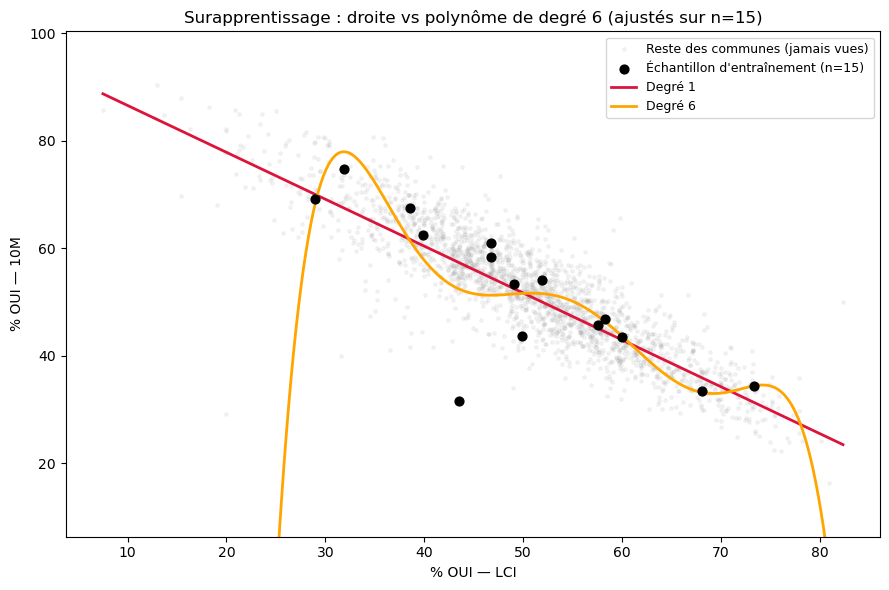

Degré   R² (entraînement, n=15)   R² (reste, jamais vu)   
1       0.643                     0.786                   
6       0.719                     -114.627                

Le polynôme de degré 6 explique mieux les 15 points d'entraînement que la droite,
mais généralise beaucoup plus mal (R² très négatif, bien pire que de prédire la
moyenne) : il a appris le bruit de cet échantillon précis, pas la tendance réelle.


In [23]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(df), size=15, replace=False)
rest_idx   = np.setdiff1d(np.arange(len(df)), sample_idx)

x_s, y_s = df['oui_pct_lci'].values[sample_idx], df['oui_pct_m10'].values[sample_idx]
x_r, y_r = df['oui_pct_lci'].values[rest_idx],   df['oui_pct_m10'].values[rest_idx]

degrees = [1, 6]
x_line = np.linspace(df['oui_pct_lci'].min(), df['oui_pct_lci'].max(), 300)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(x_r, y_r, alpha=0.08, s=6, color='grey', label='Reste des communes (jamais vues)')
ax.scatter(x_s, y_s, s=40, color='black', zorder=5, label="Échantillon d'entraînement (n=15)")

results = []
for deg, color in zip(degrees, ['crimson', 'orange']):
    coeffs = np.polyfit(x_s, y_s, deg)
    ax.plot(x_line, np.polyval(coeffs, x_line), color=color, linewidth=2, label=f'Degré {deg}')

    r2_train   = r2_score(y_s, np.polyval(coeffs, x_s))
    r2_heldout = r2_score(y_r, np.polyval(coeffs, x_r))
    results.append((deg, r2_train, r2_heldout))

ax.set_ylim(y_r.min() - 10, y_r.max() + 10)   # les oscillations du degré 6 sortent vite du cadre
ax.set_xlabel('% OUI — LCI'); ax.set_ylabel('% OUI — 10M')
ax.legend(fontsize=9)
ax.set_title('Surapprentissage : droite vs polynôme de degré 6 (ajustés sur n=15)')
plt.tight_layout()
plt.show()

print(f"{'Degré':<8}{'R² (entraînement, n=15)':<26}{'R² (reste, jamais vu)':<24}")
for deg, r2_tr, r2_ho in results:
    print(f"{deg:<8}{r2_tr:<26.3f}{r2_ho:<24.3f}")
print("\nLe polynôme de degré 6 explique mieux les 15 points d'entraînement que la droite,")
print("mais généralise beaucoup plus mal (R² très négatif, bien pire que de prédire la")
print("moyenne) : il a appris le bruit de cet échantillon précis, pas la tendance réelle.")

### 7.5 Validation — séparation entraînement / test

La démonstration précédente (§7.4) montre le symptôme du surapprentissage dans un cas extrême. En pratique, on ne compare pas visuellement des courbes : on **mesure** la capacité de généralisation avec un protocole systématique, applicable à n'importe quel modèle — même un modèle aussi simple qu'une droite OLS.

Les métriques calculées sur l'ensemble complet (`model_ols.rsquared`) restent **optimistes**, pour la même raison que ci-dessus : le modèle a été ajusté sur exactement ces données, donc il les « connaît » déjà. Pour estimer la capacité prédictive réelle (*généralisation*), on évalue le modèle sur des données qu'il n'a **jamais vues** :

1. On divise aléatoirement en **entraînement (80 %)** et **test (20 %)**.
2. On ajuste le modèle uniquement sur l'entraînement.
3. On évalue sur le test.

La §7.6 revient en détail sur les métriques utilisées pour évaluer ce modèle, et sur la question — trop souvent négligée — de savoir si le résultat obtenu est réellement bon.

In [24]:
X = df[['oui_pct_lci']].values
y = df['oui_pct_m10'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model_val = LinearRegression().fit(X_train, y_train)
y_pred_test = model_val.predict(X_test)

r2 = r2_score(y_test, y_pred_test)
print(f"Entraînement : {len(X_train)} communes   Test : {len(X_test)} communes")
print(f"R² (test) = {r2:.3f}")

Entraînement : 1679 communes   Test : 420 communes
R² (test) = 0.763


### 7.6 Métriques d'évaluation et benchmarking

Le R² calculé en §7.5 résume la performance en un seul chiffre, mais un projet de modélisation a généralement besoin d'un ensemble de **métriques** adaptées à différents usages, et surtout d'un **point de comparaison** pour savoir si ce chiffre est bon.

**Trois métriques, trois usages différents :**

| Métrique | Formule | Unité | Usage |
|---|---|---|---|
| **R²** | $1 - SS_{res}/SS_{tot}$ (§7.2) | sans unité, ∈ ]−∞, 1] | Comparer des modèles entre eux, même sur des variables cibles différentes |
| **MAE** (*Mean Absolute Error*) | $\frac{1}{n}\sum_i \lvert y_i - \hat{y}_i \rvert$ | même unité que $y$ (points de %) | Erreur « typique », facile à expliquer à un public non technique |
| **RMSE** (*Root Mean Square Error*) | $\sqrt{\frac{1}{n}\sum_i (y_i - \hat{y}_i)^2}$ | même unité que $y$ (points de %) | Comme MAE, mais pénalise davantage les grosses erreurs (utile si une grosse erreur coûte disproportionnellement plus cher) |

RMSE ≥ MAE toujours (égalité seulement si toutes les erreurs ont la même amplitude) : un grand écart entre les deux signale quelques erreurs très importantes plutôt qu'une erreur uniformément répartie.

**Le benchmarking : un chiffre seul ne veut rien dire.** Un MAE de quelques points de % est-il bon ? Impossible à dire sans **point de comparaison**. Le plus simple est un modèle **naïf** (*benchmark*) qui ignore le prédicteur et prédit toujours la moyenne d'entraînement — c'est exactement la situation $R^2 = 0$ (§7.2). Un modèle qui ne fait pas mieux que ce benchmark n'apporte **aucune information utile**, quel que soit son R² en apparence raisonnable sur le papier. On calcule ci-dessous les trois métriques pour ce benchmark et pour le modèle OLS (§7.5), sur le **même jeu de test**, pour une comparaison directe.

> 💡 **Bonne pratique** : dans un projet réel, définis ton benchmark **avant** de regarder les résultats de ton modèle. Choisir un point de comparaison après coup risque de le sélectionner, consciemment ou non, pour flatter le modèle qu'on a déjà.

In [25]:
mae  = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))

# --- Benchmark : modèle naïf qui prédit toujours la moyenne d'entraînement ---
y_pred_baseline = np.full_like(y_test, y_train.mean())
r2_base   = r2_score(y_test, y_pred_baseline)
mae_base  = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(np.mean((y_test - y_pred_baseline) ** 2))

print(f"{'Métrique':<10}{'Benchmark (moyenne)':<22}{'Modèle OLS':<12}")
print(f"{'R²':<10}{r2_base:<22.3f}{r2:<12.3f}")
print(f"{'MAE':<10}{mae_base:<22.2f}{mae:<12.2f}")
print(f"{'RMSE':<10}{rmse_base:<22.2f}{rmse:<12.2f}")
print()
print(f"Le benchmark a un R² ≈ 0 : sans surprise, « toujours prédire la moyenne » n'explique")
print(f"aucune variance (§7.2). Le modèle OLS réduit le MAE de "
      f"{100 * (1 - mae / mae_base):.0f} % par rapport à ce benchmark.")
print(f"Interprétation : en moyenne, l'erreur de prédiction du modèle est ±{mae:.1f} points de %,")
print(f"contre ±{mae_base:.1f} points de % pour le benchmark — le modèle apporte une information réelle,")
print(f"pas seulement un ajustement qui a l'air raisonnable sur le papier.")

Métrique  Benchmark (moyenne)   Modèle OLS  
R²        -0.003                0.763       
MAE       9.10                  3.86        
RMSE      11.22                 5.45        

Le benchmark a un R² ≈ 0 : sans surprise, « toujours prédire la moyenne » n'explique
aucune variance (§7.2). Le modèle OLS réduit le MAE de 58 % par rapport à ce benchmark.
Interprétation : en moyenne, l'erreur de prédiction du modèle est ±3.9 points de %,
contre ±9.1 points de % pour le benchmark — le modèle apporte une information réelle,
pas seulement un ajustement qui a l'air raisonnable sur le papier.


### 7.7 Sélection géographique vs aléatoire

Le split aléatoire de la §7.5 disperse les communes test sur tout le territoire : chaque commune test a des voisines dans l'entraînement, ce qui aide implicitement le modèle. En pratique, on souhaite souvent **prédire pour une région entière** — un canton, une zone linguistique — à partir des autres. C'est un changement de **contexte d'apprentissage** : le modèle doit généraliser à une population différente de celle sur laquelle il a été entraîné, pas seulement à de nouvelles observations de la même population.

On compare, à **effectif d'entraînement identique** (même nombre de communes des deux côtés, pour une comparaison équitable — pas le split 80/20 de la §7.5, dont les proportions diffèrent) :
- **Split aléatoire** : entraînement sur un tirage aléatoire de communes, test sur le reste, mélangés sur tout le territoire.
- **Split géographique** : entraînement uniquement sur la Suisse alémanique, test sur la Romandie et le Tessin — une région entière, jamais vue à l'entraînement.

C'est une autre facette du **surapprentissage** (§7.4) : même un modèle aussi simple qu'une droite OLS peut « surapprendre » le contexte particulier de ses données d'entraînement (ici, une région du pays), sans que cela se voie dans un split aléatoire classique.

Distribution linguistique :
region_ling
Alémanique    1344
Romand         656
Tessin          99

Effectif (identique dans les deux cas) : 1344 entraînement / 755 test
Split aléatoire     : R² = 0.807   MAE = 3.74 pts%
Split géographique  : R² = 0.602   MAE = 4.32 pts%
  (entraîné sur la Suisse alémanique → prédit Romandie + Tessin)


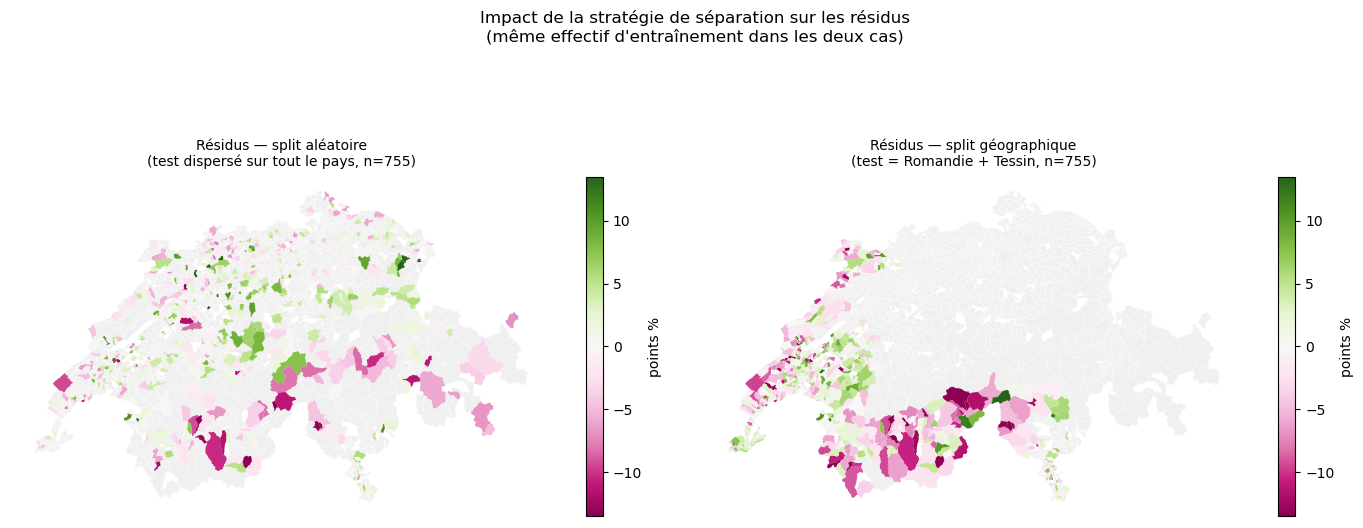

In [26]:
# Géométries des communes suisses (tp3.gpkg) pour cartographier les résidus
# GEM_TEIL == '0' : polygone principal de chaque commune (pas les enclaves)
communes_ch = (gpd.read_file('tp3.gpkg', layer='Communes')
               .to_crs('EPSG:21781'))
communes_ch = communes_ch[
    communes_ch['KANTONSNUM'].str.startswith('CH', na=False) &
    (communes_ch['GEM_TEIL'] == '0')
]

# Régions linguistiques (simplifié — cantons officiellement francophones ou italophones)
romand = {'Vaud', 'Genève', 'Neuchâtel', 'Jura', 'Fribourg', 'Valais'}
tessin = {'Tessin'}
def region(canton):
    if canton in romand: return 'Romand'
    if canton in tessin: return 'Tessin'
    return 'Alémanique'

df['region_ling'] = df['parent_canton_name'].map(region)
print("Distribution linguistique :")
print(df['region_ling'].value_counts().to_string())

mask_al = (df['region_ling'] == 'Alémanique').values
n_tr, n_te = mask_al.sum(), (~mask_al).sum()

# --- Split géographique : entraînement = Alémanique, test = Romandie + Tessin ---
model_geo = LinearRegression().fit(X[mask_al], y[mask_al])
r2_geo  = r2_score(y[~mask_al], model_geo.predict(X[~mask_al]))
mae_geo = mean_absolute_error(y[~mask_al], model_geo.predict(X[~mask_al]))

# --- Split aléatoire à effectif IDENTIQUE (n_tr entraînement / n_te test) ---
# Un modèle réajusté sur les 2099 communes (comme model_ols en §7.3) aurait déjà "vu"
# les communes de test : ce ne serait pas une évaluation hors échantillon valable.
rng_split = np.random.default_rng(42)
perm = rng_split.permutation(len(df))
idx_tr_rand, idx_te_rand = perm[:n_tr], perm[n_tr:n_tr + n_te]

model_rand = LinearRegression().fit(X[idx_tr_rand], y[idx_tr_rand])
r2_rand  = r2_score(y[idx_te_rand], model_rand.predict(X[idx_te_rand]))
mae_rand = mean_absolute_error(y[idx_te_rand], model_rand.predict(X[idx_te_rand]))

print(f"\nEffectif (identique dans les deux cas) : {n_tr} entraînement / {n_te} test")
print(f"Split aléatoire     : R² = {r2_rand:.3f}   MAE = {mae_rand:.2f} pts%")
print(f"Split géographique  : R² = {r2_geo:.3f}   MAE = {mae_geo:.2f} pts%")
print("  (entraîné sur la Suisse alémanique → prédit Romandie + Tessin)")

# --- Cartes des résidus, rattachées à la géométrie communale ---
df_rand_te = df.iloc[idx_te_rand].copy()
df_rand_te['resid_rand'] = y[idx_te_rand] - model_rand.predict(X[idx_te_rand])
gdf_rand = communes_ch[['NAME', 'geometry']].merge(
    df_rand_te[['region_name', 'resid_rand']], left_on='NAME', right_on='region_name', how='inner')

df_geo_te = df.loc[~mask_al].copy()
df_geo_te['resid_geo'] = y[~mask_al] - model_geo.predict(X[~mask_al])
gdf_geo = communes_ch[['NAME', 'geometry']].merge(
    df_geo_te[['region_name', 'resid_geo']], left_on='NAME', right_on='region_name', how='inner')

vabs = max(gdf_rand['resid_rand'].abs().quantile(0.97), gdf_geo['resid_geo'].abs().quantile(0.97))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

communes_ch.plot(ax=axes[0], color='#f0f0f0', edgecolor='white', linewidth=0.2)
gdf_rand.plot(ax=axes[0], column='resid_rand', cmap='PiYG', vmin=-vabs, vmax=vabs, legend=True,
              legend_kwds={'shrink': 0.65, 'label': 'points %'}, edgecolor='none')
axes[0].set_title(f'Résidus — split aléatoire\n(test dispersé sur tout le pays, n={n_te})', fontsize=10)
axes[0].set_axis_off()

communes_ch.plot(ax=axes[1], color='#f0f0f0', edgecolor='white', linewidth=0.2)
gdf_geo.plot(ax=axes[1], column='resid_geo', cmap='PiYG', vmin=-vabs, vmax=vabs, legend=True,
             legend_kwds={'shrink': 0.65, 'label': 'points %'}, edgecolor='none')
axes[1].set_title(f'Résidus — split géographique\n(test = Romandie + Tessin, n={n_te})', fontsize=10)
axes[1].set_axis_off()

plt.suptitle("Impact de la stratégie de séparation sur les résidus\n(même effectif d'entraînement dans les deux cas)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Récapitulatif

### Parties 1–6 — Géotraitements vectoriels avec GeoPandas

| Opération QGIS | Code Python |
|---|---|
| Sélection par expression | `gdf[gdf['col'] == val]`, `.isin()`, `.query()` |
| Sélection par localisation | `gpd.sjoin(predicate='intersects')` |
| Jointure attributaire | `df.merge(other, left_on=..., right_on=...)` |
| Relation N-N | double `merge()` via table intermédiaire |
| Carte choroplèthe | `.plot(column=..., scheme=..., cmap=...)` |
| Export GeoJSON / GPKG / SHP | `.to_file(driver=...)` |

### Partie 7 — Régression linéaire et validation

| Étape | Code clé |
|---|---|
| Corrélation de Pearson | `scipy.stats.pearsonr(x, y)` |
| OLS avec intervalles | `smf.ols(...).fit()` + `.get_prediction().summary_frame()` |
| Démonstration du surapprentissage | `np.polyfit(x, y, deg=6)` sur un petit échantillon |
| Split entraînement/test | `train_test_split(X, y, test_size=0.2)` |
| Métriques | `r2_score`, `mean_absolute_error`, RMSE via `np.sqrt(np.mean((y_true - y_pred)**2))` |
| Benchmark | comparer aux métriques d'un modèle naïf (prédire la moyenne d'entraînement) |
| Split géographique | entraîner sur un sous-ensemble régional, évaluer sur le reste |

**Points clés à retenir :**
- $R^2 = 1 - SS_{res}/SS_{tot}$ ; pour une régression simple à un prédicteur, $R^2 = r^2$.
- **R² est sans unité** (comparer des modèles) ; **MAE et RMSE sont dans l'unité de $y$** (interpréter une erreur concrète) ; RMSE ≥ MAE toujours, l'écart entre les deux révèle des erreurs ponctuellement grandes.

### 🎯 Bonnes pratiques ML — niveau 1 : les fondamentaux

| Principe | Où on l'a vu |
|---|---|
| Ne **jamais** évaluer un modèle sur les données qui ont servi à l'entraîner — la performance mesurée est alors optimiste | §7.4 (surapprentissage), §7.5 (train/test) |
| Toujours comparer à un **benchmark** — un chiffre de performance seul ne veut rien dire, même s'il « a l'air raisonnable » | §7.6 |
| Choisir la métrique adaptée à la question : **R²** pour comparer des modèles, **MAE/RMSE** pour une erreur directement interprétable | §7.6 |
| Réfléchir à **qui** compose le jeu de test, pas seulement à sa taille — un split aléatoire peut cacher un échec de généralisation qu'un split structuré (ici, géographique) révèle | §7.7 |

Ces quatre principes sont les fondations de tout projet de modélisation, indépendamment du modèle utilisé. Le **TP03** les enrichit (comparer plusieurs modèles avec une procédure commune, quantifier l'incertitude d'une estimation de performance) et le **TP04** les complète (jeu de validation dédié à la sélection de modèle, garanties de fiabilité mesurables).

---
## ✅ Validation du TP

Ton notebook est terminé ! Il te reste à valider ce volet Python sur Moodle.

| Activité | Où ? |
|----------|------|
| Questions CodeRunner du TP2 (à soumettre dans Moodle) | [CodeRunner\_TP2]({{ MOODLE_CODERUNNER_TP2 }}) |

> La page d'accueil du TP indique la section **Évaluation et rendus** (quiz théorique, questions CodeRunner, dépôts) : [retour au TP2](tp02.md).
